In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import os

#to get font to work
font_dir = os.path.expanduser("/home/mbrannon/.fonts")
font_files = fm.findSystemFonts(fontpaths=[font_dir])
for font_file in font_files:
    fm.fontManager.addfont(font_file)
plt.rcParams["font.family"] = "IBM Plex Sans"
rcParams["font.sans-serif"] = ["IBM Plex Sans"]


In [15]:
#This file is an output from running predict_cell_type from vinson
pearson_df = pd.read_table('/home/mbrannon/tmp/ag_preds_nll/metrics_summary.txt')

In [39]:
pearson_df=pearson_df.rename(columns={'AG_ID': 'ag_id', "Pearson":"pearson_r"})

In [40]:
meta = pd.read_table('/home/mbrannon/tmp/ag_metadata.tsv')
merged = pearson_df.merge(meta, on="ag_id")

In [18]:
#add colors to match 
#mouse
#ann data colors
mouse_colors = {
    'AML':"#8977a6",
    "Adipose": "#feff55", 
    "Adrenal": "#6ce2fb",
    "Blastoma": "#e091a9",
    "Bladder":"#ffde59",
    "B-cell": "#eb5a4f",
    'Brain':"#fadce5",
    "Cerebellum":"#0e00a0",
    "Cerebrum":"#0e00a5",
    "Cerebral cortex":"#90fcb3",
    "Embryonic germ layer":"#a1659e",
    "Erythroid":"#520b0b",
    "Eye":"#849693",
    "Fibroblast":"#26430e",
    'Forebrain':"#fadce5",
    "Heart":"#71c43b",
    "Hindbrain":"#71c43b",
    "Kidney":"#d7800c",
    "Large intestine":"#483c51",
    "Limbic system":"#133247",
    "Lung":"#aa2617",
    "Midbrain":"#6f7822",
    "Limbic System":"#4dadfe",
    "Liver":"#fadce5",
    "Lymphoma":"#ff0036",
    "Monocyte":"#f4af97",
    "Muscle":"#f195c6",
    "NK-cell":"#e1eefe",
    "Ovary":"#75524d",
    "Pluripotent/Pluripotent-derived":"#2b0316",
    "Stomach":"#458e7d",
    "T-cell":"#f4b840",
    "Testis":"#cefeed",
}

In [19]:
#add colors to match human
#ann data colors
human_colors = {
    "ALL":"#77a69e",
    'AML':"#8977a6",
    'APL':"#a69077",
    "Adipose": "#feff55",  
    "Adrenal": "#6ce2fb",
    'Astrocyte':"#eb49f8",
    "Blastoma": "#e091a9",
    "B-cell": "#eb5a4f",
    "Basal ganglia":"#3c884a",
    "Bladder":"#ffde59",
    "Bone":"#306da1",
    'Bone marrow':"#951d58",
    'Brain stem':"#fadce5",
    "CMP":"#734b16",
    "CML":"#a1659e",
    "Carcinoma":"#96ce72",
    "Cerebellum":"#0e00a0",
    "Cerebral cortex":"#90fcb3",
    "Colon":"#b39869",
    "Dendritic":"#1e4c43",
    "Endothelium":"#96affa",
    "Epithelium":"#957e86",
    "Erythroid":"#520b0b",
    "Eye":"#849693",
    "Liposarcoma":"#5c3948",
    "Fetal life support":"#633c4d",
    "Fibroblast":"#26430e",
    "Gallbladder":"#d8d930",
    "Heart":"#71c43b",
    "Hepatic":"#71c43b",
    "Intestine":"#483c51",
    "Limbic system":"#61615b",
    "Lymphoma":"#d7800c",
    "Kidney":"#d7800c",
    "Lung":"#aa2617",
    "Macrophage":"#6f7822",
    "Mammary adenocarcinoma":"#4dadfe",
    "Mammary ductal carcinoma":"#fadce5",
    "Melanocyte":"#57bfa2",
    "Myoblast":"#aa24a4",
    "Myeloma":"#e7d2d9",
    "Myocyte":"#c36726",
    "Monocyte":"#f4af97",
    "Muscle":"#f195c6",
    "NK-cell":"#e1eefe",
    "Nerve":"#010032",
    "Non-SCLC":"#bf564a",
    "Ovary":"#75524d",
    "Pancreas":"#a7c19d",
    "Plasmacytoma":"#ff0036",
    "Pluripotent/Pluripotent-derived":"#2b0316",
    "Prostate":"#2b0316",
    "Rhaboid tumor":"#63545b",
    "SCLC":"#7b678a",
    "Sarcoma":"#5c394c",
    "Spinal cord":"#133247",
    "Stomach":"#458e7d",
    "Stroma":"#352207",
    "T-cell":"#f4b840",
    "Testis":"#cefeed",
    "Thyroid":"#9a7bbb",
    "Ureter":"#a7b717",
    "Uterus":"#bb2948",
}

In [41]:
#add custom colors
annotation_color = human_colors
merged["color"] = merged["extended_annotation"].map(annotation_colors)

#sort by annotation
merged = merged.sort_values(by=["extended_annotation", "ag_id"])

# Make ag_id a categorical variable with this sorted order
merged["ag_id"] = pd.Categorical(
    merged["ag_id"], 
    categories=merged["ag_id"].unique(), 
    ordered=True
)

In [42]:
#get list of ags used for training
combined = set(pd.read_csv("/home/mbrannon/tmp/trained_id.csv")["ag_id"].tolist())


In [22]:
merged

,ag_id,Pearson,Mean_NLL,ds_number,extended_annotation,SPOT3_score,pathological_state,color
1923,AG80012,0.6512,0.2475,DS71539,ALL,0.546045,Cancer,#77a69e
1922,AG80013,0.6885,0.2011,DS71524,ALL,0.505672,Cancer,#77a69e
1919,AG80015,0.6574,0.4910,DS71539,ALL,0.658414,Cancer,#77a69e
1930,AG80017,0.6757,0.4712,DS71524,ALL,0.602724,Cancer,#77a69e
2553,AG80775,0.5812,0.3286,DS12659,ALL,0.380720,Cancer,#77a69e
...,...,...,...,...,...,...,...,...
1905,AG79993,0.6231,0.0931,DS72984,Thyroid,0.626020,Normal,#9a7bbb
1946,AG80037,0.7753,0.0489,DS70503,Ureter,0.115533,Normal,#a7b717
741,AG6260,0.7598,0.0536,DS40116,Uterus,0.170405,Normal,#bb2948
1893,AG79973,0.7182,0.1396,DS73091,Uterus,0.308782,Normal,#bb2948


In [43]:
# Add a column for training status
merged["training_status"] = merged["ag_id"].isin(combined).map(
    {True: "Training", False: "Not Training"}
)
#separate by cancer
merged["annotation_group"] = (
    merged["extended_annotation"] + " (" + merged["pathological_state"] + ")"
)

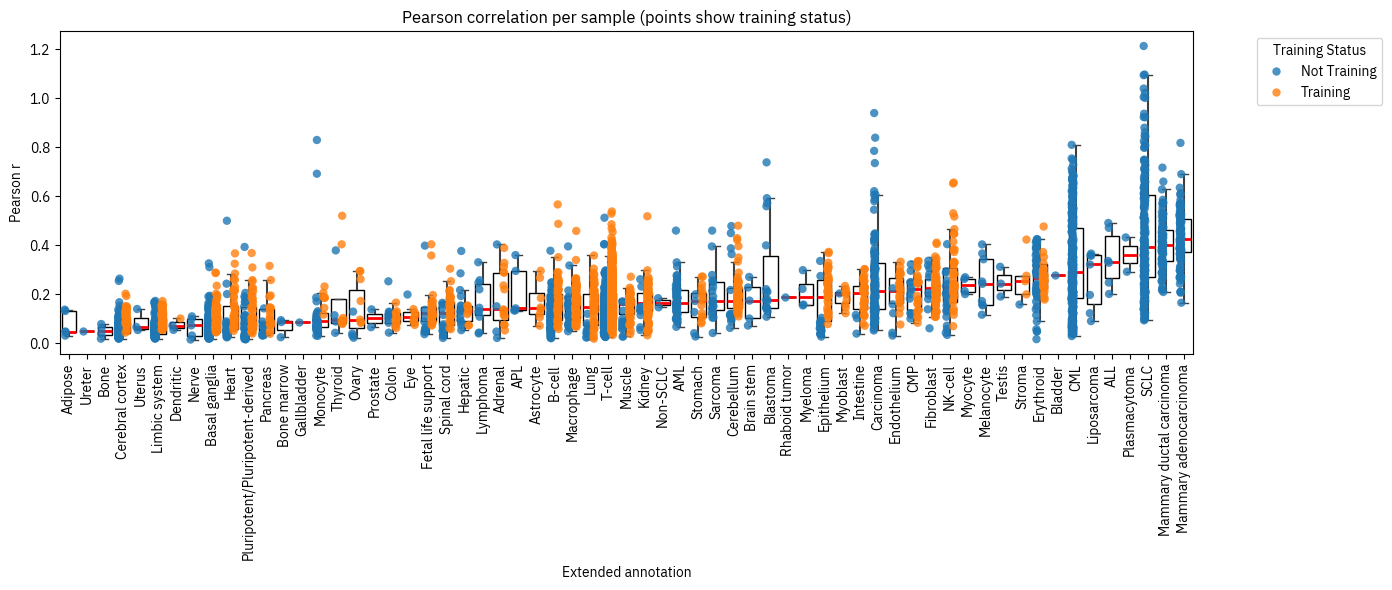

In [29]:
# Compute combined order by median correlation
order = (
    merged.groupby("extended_annotation")["Mean_NLL"]
    .median()
    .sort_values()
    .index
)


plt.figure(figsize=(14, 6))

# Boxplot (overall distribution)
sns.boxplot(
    data=merged,
    x="extended_annotation",
    y="Mean_NLL",
    order=order,
    showcaps=True,
    boxprops={'facecolor':'none', "edgecolor":"black"},
    showfliers=False,
    whiskerprops={'linewidth':1.5},
    medianprops={'color':'red', 'linewidth':2}
)

# Overlay individual points, colored by training status
sns.stripplot(
    data=merged,
    x="extended_annotation",
    y="Mean_NLL",
    hue="training_status",
    order=order,
    dodge=True,          # separates points slightly by hue
    jitter=True,         # spread points for visibility
    marker="o",
    size=6,
    alpha=0.8
)

plt.xticks(rotation=90)
plt.xlabel("Extended annotation")
plt.ylabel("Pearson r")
plt.title("Pearson correlation per sample (points show training status)")

plt.legend(title="Training Status", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

/tmp/ipykernel_13423/2846606718.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


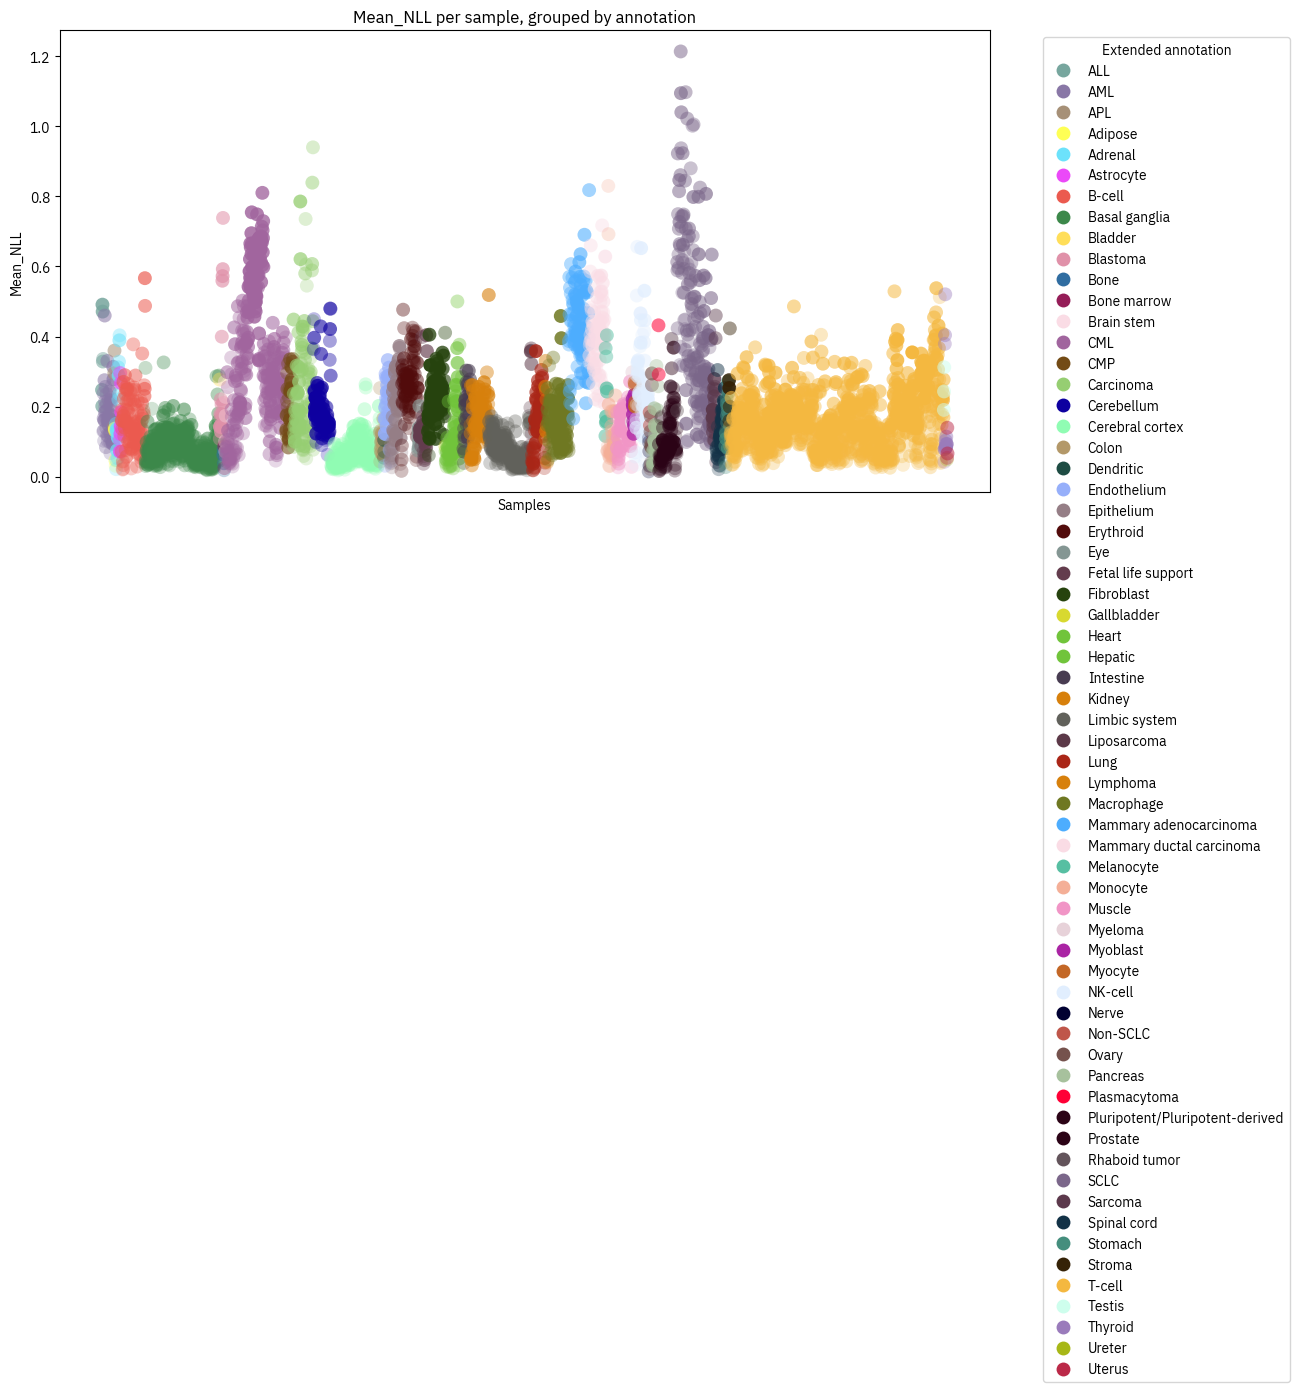

In [30]:
plt.figure(figsize=(12, 6))

#Normalize SPOT3_score for alpha scaling (0 → 0.2, 1 → 1 for example)
alpha_vals = (merged["SPOT3_score"] - merged["SPOT3_score"].min()) / (
    merged["SPOT3_score"].max() - merged["SPOT3_score"].min()
)
alpha_vals = 0.2 + 0.8 * alpha_vals  # ensures min alpha=0.2, max alpha=1

sns.scatterplot(
    data=merged,
    x="ag_id",
    y="Mean_NLL",
    hue="extended_annotation",
    palette=annotation_colors,
    s=100,
    linewidth=0.1,  # thin outline
    edgecolor="none",  # no black edges
    alpha=None  # we'll pass per-point alpha below
)

# Apply alpha manually
for i, artist in enumerate(plt.gca().collections[0].get_paths()):
    plt.gca().collections[0].set_alpha(None)  # disable global alpha
for collection, a in zip(plt.gca().collections, [alpha_vals]):
    collection.set_alpha(None)  # remove global alpha
    collection.set_facecolors([
        (*fc[:3], a)  # keep original RGB, replace alpha
        for fc, a in zip(collection.get_facecolors(), alpha_vals)
    ])

plt.xticks([], [])
plt.xlabel("Samples")
plt.ylabel("Mean_NLL")
plt.title("Mean_NLL per sample, grouped by annotation")
plt.legend(title="Extended annotation", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


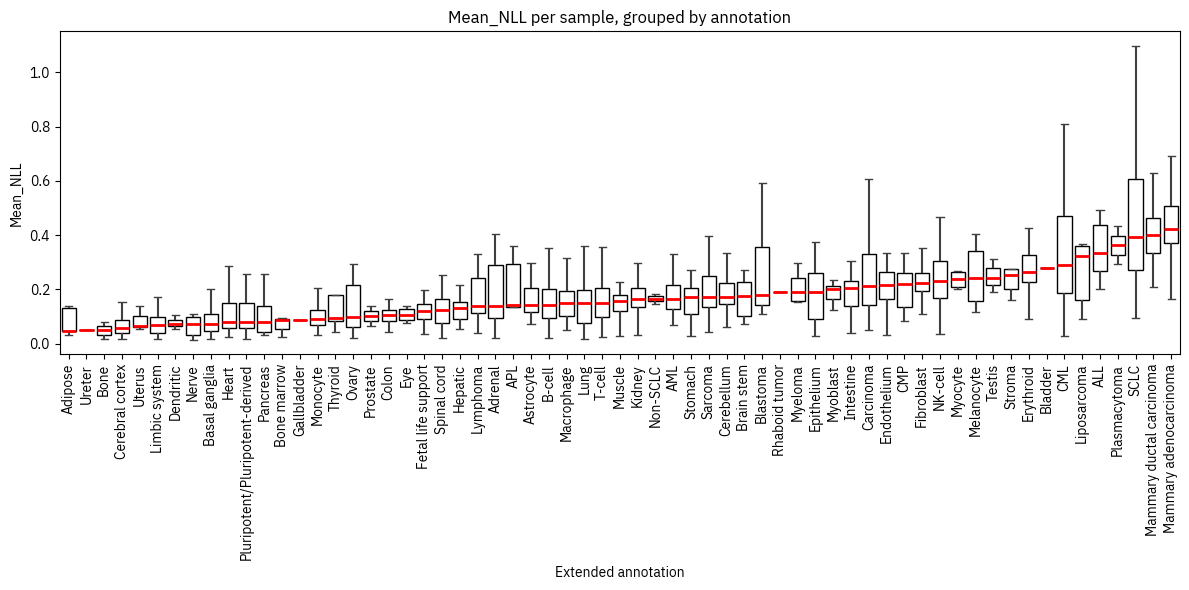

In [31]:
# Compute medians
order = (
    merged.groupby("extended_annotation")["Mean_NLL"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=merged,
    x="extended_annotation",
    y="Mean_NLL",
    order=order,  # <- order by median
    showcaps=True,
    boxprops={'facecolor':'none', "edgecolor":"black"},
    showfliers=False,
    whiskerprops={'linewidth':1.5},
    medianprops={'color':'red', 'linewidth':2}
)

plt.xticks(rotation=90)
plt.xlabel("Extended annotation")
plt.ylabel("Mean_NLL")
plt.title("Mean_NLL per sample, grouped by annotation")
plt.legend([], [], frameon=False)  # remove duplicate legend
plt.tight_layout()
plt.show()


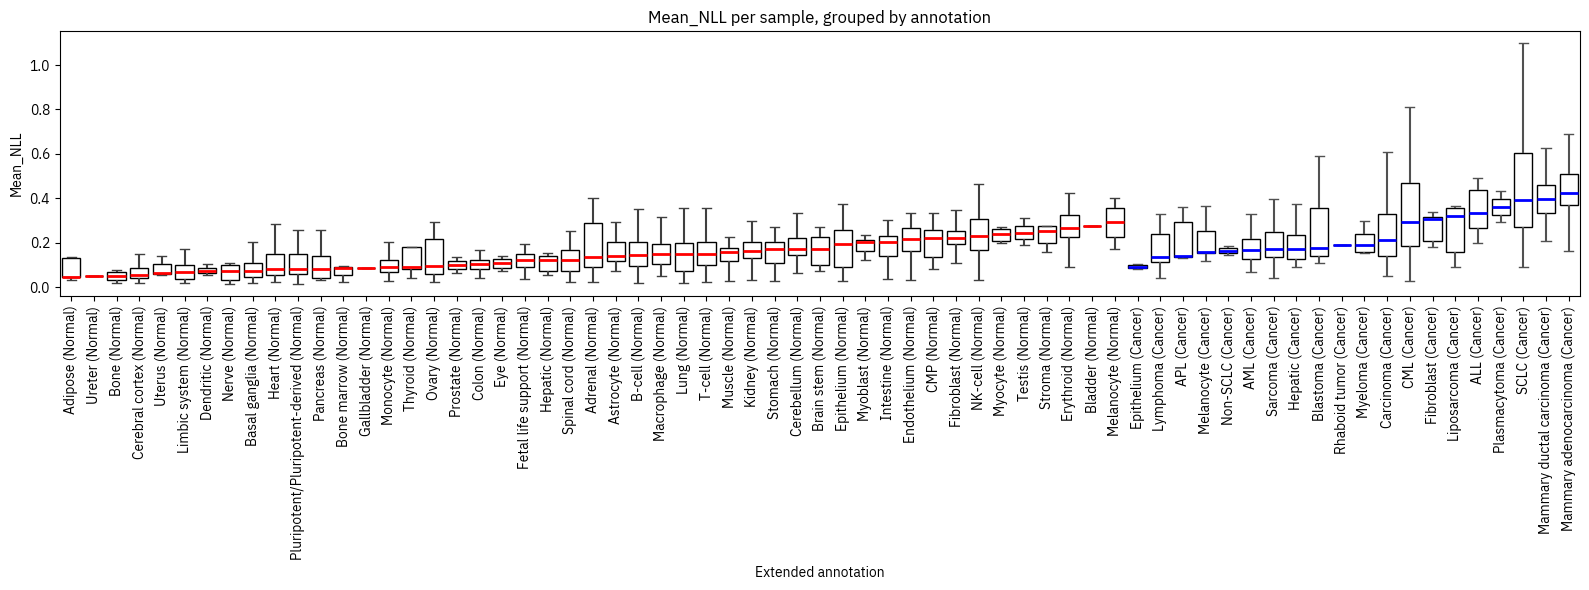

In [32]:
# Split cancer vs non-cancer
normal_df = merged[merged["pathological_state"] == "Normal"]
cancer_df = merged[merged["pathological_state"] == "Cancer"]


# Compute order separately
order_normal = (
    normal_df.groupby("annotation_group")["Mean_NLL"]
    .median()
    .sort_values()
    .index
)
order_cancer = (
    cancer_df.groupby("annotation_group")["Mean_NLL"]
    .median()
    .sort_values()
    .index
)

# Combine order: Normal first, then Cancer
combined_order = list(order_normal) + list(order_cancer)

plt.figure(figsize=(16, 6))

# Plot Normal first (red medians)
sns.boxplot(
    data=normal_df,
    x="annotation_group",
    y="Mean_NLL",
    order=combined_order,
    showcaps=True,
    boxprops={'facecolor':'none', "edgecolor":"black"},
    showfliers=False,
    whiskerprops={'linewidth':1.5},
    medianprops={'color':'red', 'linewidth':2},
)

# Overlay Cancer (blue medians)
sns.boxplot(
    data=cancer_df,
    x="annotation_group",
    y="Mean_NLL",
    order=combined_order,
    showcaps=True,
    boxprops={'facecolor':'none', "edgecolor":"black"},
    showfliers=False,
    whiskerprops={'linewidth':1.5},
    medianprops={'color':'blue', 'linewidth':2},
)

plt.xticks(rotation=90)
plt.xlabel("Extended annotation")
plt.ylabel("Mean_NLL")
plt.title("Mean_NLL per sample, grouped by annotation")
plt.tight_layout()
plt.show()


TypeError: alpha must be numeric or None, not <class 'pandas.core.series.Series'>

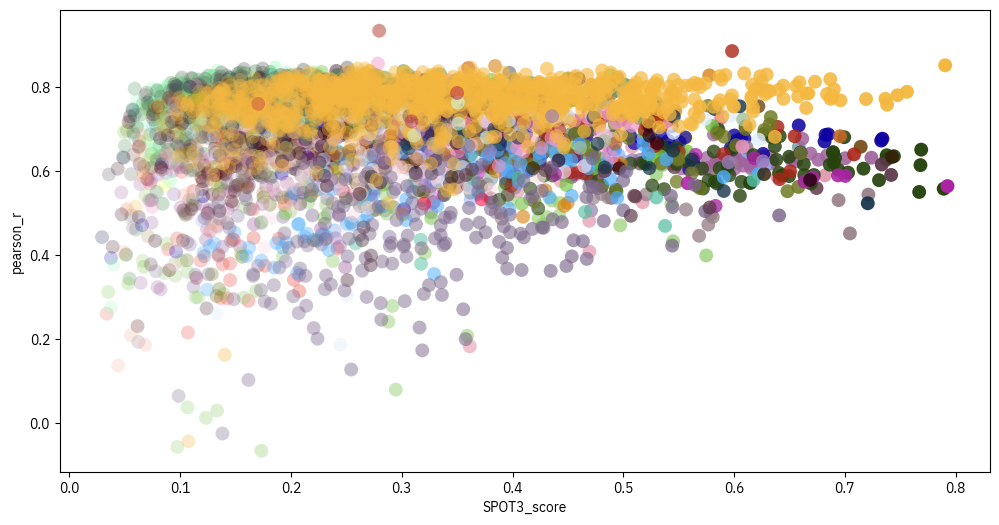

In [45]:
plt.figure(figsize=(12, 6))

alpha_vals = (merged["SPOT3_score"] - merged["SPOT3_score"].min()) / (
    merged["SPOT3_score"].max() - merged["SPOT3_score"].min()
)
alpha_vals = 0.2 + 0.8 * alpha_vals  # ensures min alpha=0.2, max alpha=1

sns.scatterplot(
    data=merged,
    x="SPOT3_score",
    y="pearson_r",
    hue="extended_annotation",
    palette=annotation_colors,
    s=100,
    linewidth=0.1,
    edgecolor="none",
    alpha=alpha_vals
)

plt.xlabel("SPOT3_score")
plt.ylabel("Pearson r")
plt.title("Pearson correlation vs SPOT3_score")
plt.legend(title="Extended annotation", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


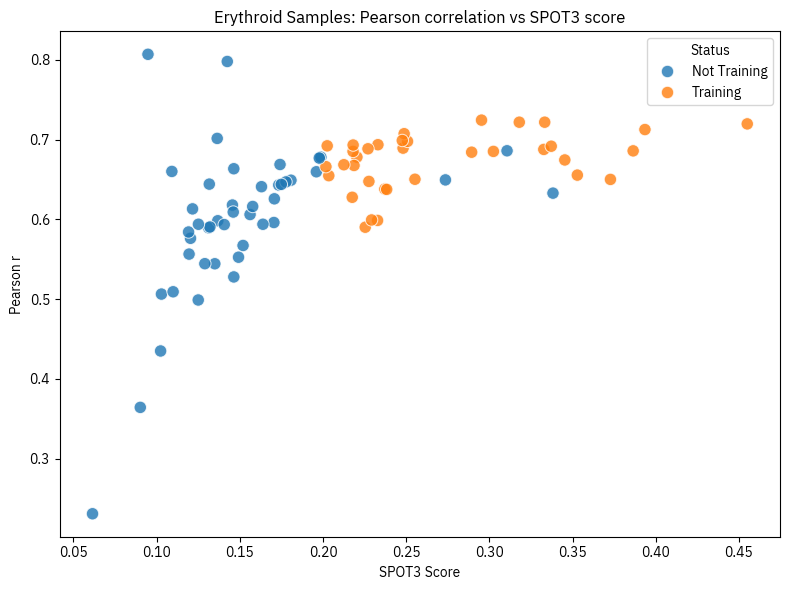

In [48]:
# Subset to B cells
cell_type = "Erythroid"
cell_df = merged[merged["extended_annotation"].str.contains(cell_type, case=False, na=False)].copy()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=cell_df,
    x="SPOT3_score",
    y="pearson_r",
    hue="training_status",   # optional: color by training status if column exists
    s=80,
    alpha=0.8
)

plt.xlabel("SPOT3 Score")
plt.ylabel("Pearson r")
plt.title(f"{cell_type} Samples: Pearson correlation vs SPOT3 score")
plt.legend(title="Status")
plt.tight_layout()
plt.show()
